In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load Dataset
df = pd.read_csv("social_media_engagement_5000.csv")

# Display first 5 rows
df.head()

# Display last 5 rows
df.tail()

# Shape of dataset
print("Shape:", df.shape)

# Column Names
print(df.columns)

# Data Types
print(df.dtypes)

# Dataset Information
df.info()

# Convert date column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'])

# Verify datatype
print(df['posted_at'].dtype)

Shape: (5000, 19)
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            N

/tmp/ipykernel_651/3906436749.py:30: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


In [3]:
# Check Missing Values
print(df.isnull().sum())

# Fill Missing Numeric Values
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Missing Categorical Values
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# Convert Date Column
df['posted_at'] = pd.to_datetime(df['posted_at'])

# Standardize Text
df['gender'] = df['gender'].str.title()
df['sentiment'] = df['sentiment'].str.lower()

# Convert Negative Values to Positive
for col in ['likes','comments','shares','watch_time_sec','impression_count','follower_count']:
    df[col] = df[col].abs()

# Create Hashtag Count
df['hashtag_count'] = df['hashtags'].str.count('#')

print("Data Cleaning Completed Successfully")

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
Data Cleaning Completed Successfully


In [4]:
# -----------------------------
# TASK 3 - DATA EXPLORATION
# -----------------------------

# First 5 Rows
print("First 5 Rows:")
print(df.head())

# Last 5 Rows
print("\nLast 5 Rows:")
print(df.tail())

# Shape
print("\nDataset Shape:")
print(df.shape)

# Column Names
print("\nColumns:")
print(df.columns)

# Data Information
print("\nDataset Info:")
df.info()

# Data Types
print("\nData Types:")
print(df.dtypes)

# Summary Statistics
print("\nSummary Statistics:")
print(df.describe())

# Unique Values
print("\nUnique Values:")
print(df.nunique())

# Value Counts for Categorical Columns
print("\nGender Distribution:")
print(df['gender'].value_counts())

print("\nPost Type Distribution:")
print(df['post_type'].value_counts())

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# Correlation Matrix
print("\nCorrelation Matrix:")
print(df.select_dtypes(include=['number']).corr())

# Average Likes by Post Type
print("\nAverage Likes by Post Type:")
print(df.groupby('post_type')['likes'].mean())

# Average Impressions by Country
print("\nAverage Impressions by Country:")
print(df.groupby('country')['impression_count'].mean())

First 5 Rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        Fals

In [5]:
# -----------------------------
# TASK 4 - DATA WRANGLING
# -----------------------------

# Create Engagement Score
df['engagement_score'] = (
    df['likes'] +
    df['comments'] +
    df['shares']
)

# Log Transformed Likes (Optional)
df['log_likes'] = np.log1p(df['likes'])

# Group by Post Type
print("\nAverage Engagement Score by Post Type")
print(df.groupby('post_type')['engagement_score'].mean())

# Group by Country
print("\nAverage Engagement Score by Country")
print(df.groupby('country')['engagement_score'].mean())

# Group by Sentiment
print("\nAverage Engagement Score by Sentiment")
print(df.groupby('sentiment')['engagement_score'].mean())

# Top 10 Posts
top_posts = df.sort_values(by='engagement_score', ascending=False)

print("\nTop 10 Posts")
print(top_posts[['post_id','engagement_score']].head(10))


Average Engagement Score by Post Type
post_type
image    12649.390537
reel     12524.031567
text     12613.243775
video    12664.594286
Name: engagement_score, dtype: float64

Average Engagement Score by Country
country
Australia    12809.621704
Brazil       12385.983135
Canada       12605.894737
France       12903.384073
Germany      12635.664286
India        12492.701869
Japan        12578.648305
UAE          12757.777336
UK           12384.374239
USA          12575.461078
Name: engagement_score, dtype: float64

Average Engagement Score by Sentiment
sentiment
negative    12731.498958
neutral     12448.163720
positive    12665.799443
Name: engagement_score, dtype: float64

Top 10 Posts
      post_id  engagement_score
41     147547           24680.0
1632   641620           24583.0
3814   943395           24509.0
3223   182790           24486.0
2998   462928           24423.0
1605   716963           24383.0
3741   422233           24239.0
2198   647678           24221.0
4495   160384  

In [6]:
# -----------------------------
# TASK 5 - STATISTICAL ANALYSIS
# -----------------------------

columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

for col in columns:
    print("\n==============================")
    print("Column:", col)
    print("==============================")

    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())
    print("Variance:", df[col].var())

    print("25%:", df[col].quantile(0.25))
    print("50%:", df[col].quantile(0.50))
    print("75%:", df[col].quantile(0.75))

    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())


Column: likes
Mean: 10106.9974
Median: 10105.5
Mode: 10105.5
Standard Deviation: 5702.293017183876
Variance: 32516145.653823998
25%: 5235.0
50%: 10105.5
75%: 14959.0
Skewness: -0.006893616532184278
Kurtosis: -1.1499923609078424

Column: comments
Mean: 1502.0398
Median: 1497.0
Mode: 1497.0
Standard Deviation: 856.3933120458967
Variance: 733409.5049169405
25%: 792.0
50%: 1497.0
75%: 2235.25
Skewness: 0.0038017289479831415
Kurtosis: -1.1443748352968992

Column: shares
Mean: 1002.9106
Median: 1012.0
Mode: 1012.0
Standard Deviation: 570.8551999758862
Variance: 325875.65933950903
25%: 511.0
50%: 1012.0
75%: 1483.0
Skewness: -0.014653583910311461
Kurtosis: -1.1468565626589917

Column: watch_time_sec
Mean: 4014.5032
Median: 4034.5
Mode: 916
Standard Deviation: 2308.096459042085
Variance: 5327309.26424261
25%: 2017.75
50%: 4034.5
75%: 6020.25
Skewness: -0.018196273193231846
Kurtosis: -1.195651797070188

Column: engagement_rate
Mean: 0.9643560291583999
Median: 0.2538959065
Mode: 0.006362909
Sta

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

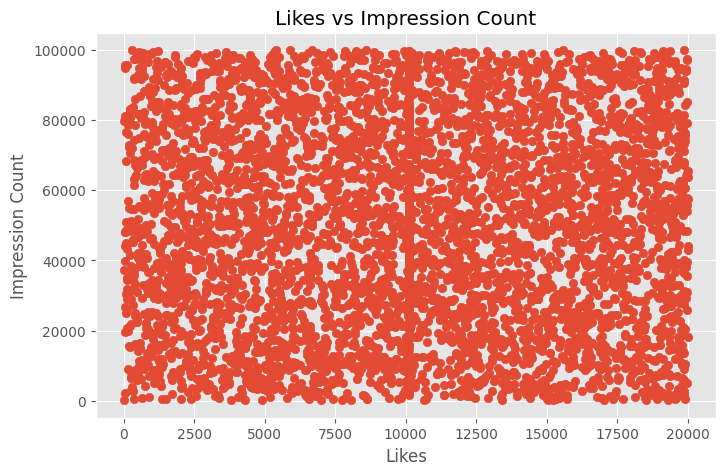

Conclusion:
Posts with more likes generally tend to receive higher impressions.


In [11]:
# =====================================================
# CHART 1 : Scatter Plot
# =====================================================
# Title:
# Likes vs Impression Count
#
# Objective:
# To analyze the relationship between likes and impressions.
# =====================================================
plt.figure(figsize=(8,5))
plt.scatter(df['likes'], df['impression_count'])
plt.title("Likes vs Impression Count")
plt.xlabel("Likes")
plt.ylabel("Impression Count")
plt.grid(True)
plt.show()

print("Conclusion:")
print("Posts with more likes generally tend to receive higher impressions.")

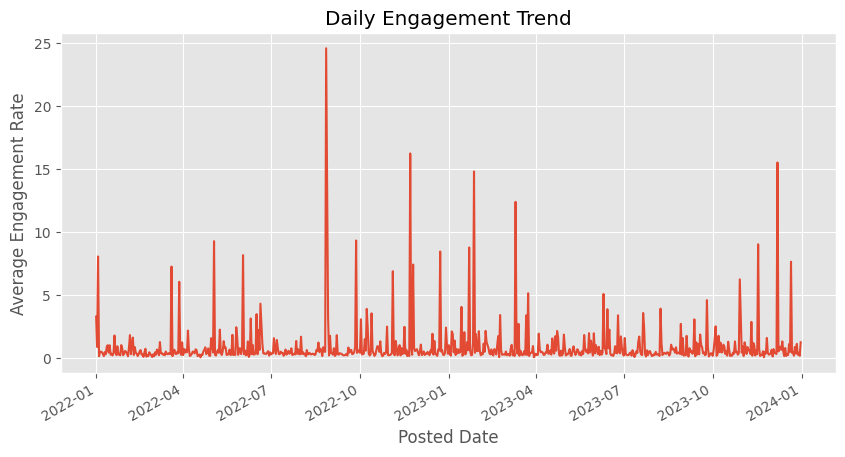

Conclusion:
The chart shows how average engagement changes across posting dates.


In [12]:
# CHART 2: line Chart
# =====================================================
# CHART 2 : Daily Engagement Trend
# Objective :
# To analyze engagement rate over time.
# =====================================================

daily = df.groupby('posted_at')['engagement_rate'].mean()

plt.figure(figsize=(10,5))
daily.plot()
plt.title("Daily Engagement Trend")
plt.xlabel("Posted Date")
plt.ylabel("Average Engagement Rate")
plt.grid(True)
plt.show()

print("Conclusion:")
print("The chart shows how average engagement changes across posting dates.")

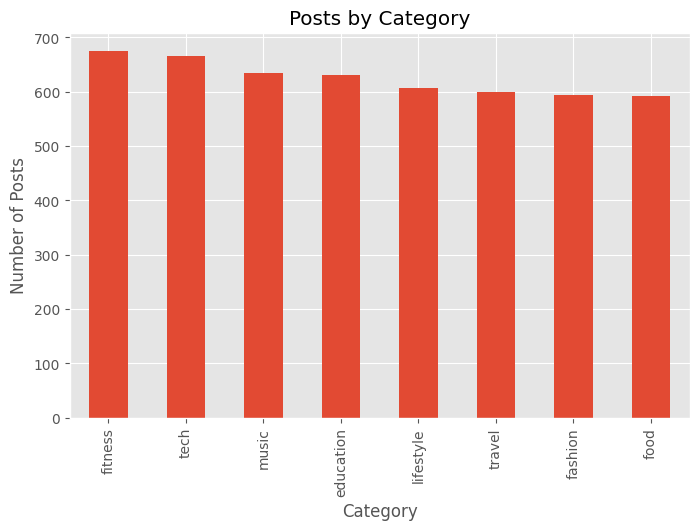

Conclusion:
The bar chart identifies the category with the highest number of posts.


In [13]:
# Chart 3 – Bar Chart
# =====================================================
# CHART 3 : Posts by Category
# Objective :
# To compare the number of posts in each category.
# =====================================================

plt.figure(figsize=(8,5))
df['post_category'].value_counts().plot(kind='bar')
plt.title("Posts by Category")
plt.xlabel("Category")
plt.ylabel("Number of Posts")
plt.grid(True)
plt.show()

print("Conclusion:")
print("The bar chart identifies the category with the highest number of posts.")

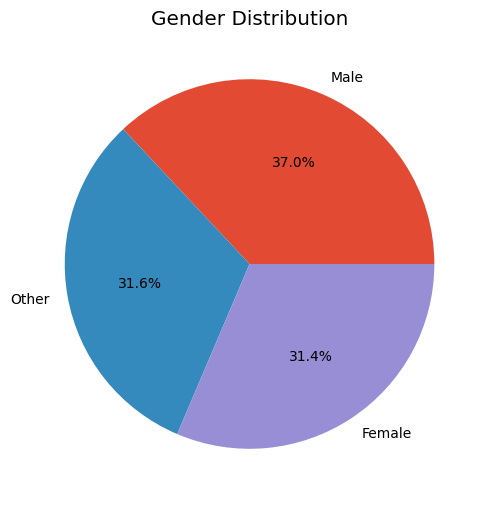

Conclusion:
The pie chart shows the percentage distribution of users by gender.


In [14]:
# Chart 4 – Pie Chart
# =====================================================
# CHART 4 : Gender Distribution
# Objective :
# To analyze the gender distribution of users.
# =====================================================

plt.figure(figsize=(6,6))
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

print("Conclusion:")
print("The pie chart shows the percentage distribution of users by gender.")

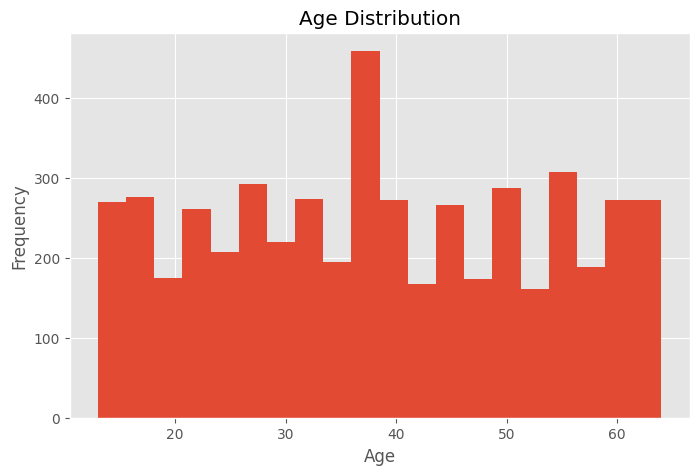

Conclusion:
The histogram displays how users are distributed across different age groups.


In [15]:
# Chart 5 – Histogram
# =====================================================
# CHART 5 : Age Distribution
# Objective :
# To understand the distribution of users' ages.
# =====================================================

plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

print("Conclusion:")
print("The histogram displays how users are distributed across different age groups.")

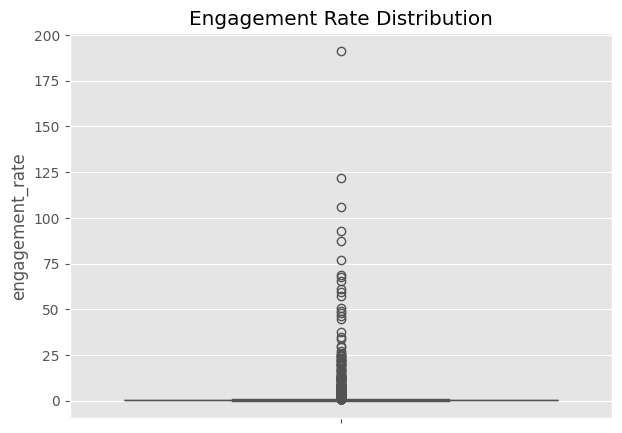

Conclusion:
The box plot highlights the spread of engagement rate and potential outliers.


In [16]:
# Chart 6 – Box Plot
# =====================================================
# CHART 6 : Engagement Rate Distribution
# Objective :
# To identify outliers in engagement rate.
# =====================================================

plt.figure(figsize=(7,5))
sns.boxplot(y=df['engagement_rate'])

plt.title("Engagement Rate Distribution")
plt.show()

print("Conclusion:")
print("The box plot highlights the spread of engagement rate and potential outliers.")

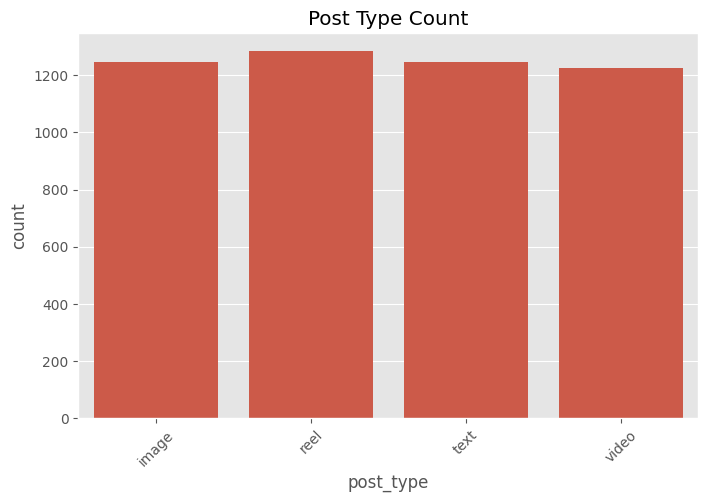

Conclusion:
The count plot shows the frequency of each post type.


In [17]:
# Chart 7 – Count Plot
# =====================================================
# CHART 7 : Post Type Count
# Objective :
# To compare the number of posts by post type.
# =====================================================

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='post_type')

plt.title("Post Type Count")
plt.xticks(rotation=45)
plt.show()

print("Conclusion:")
print("The count plot shows the frequency of each post type.")

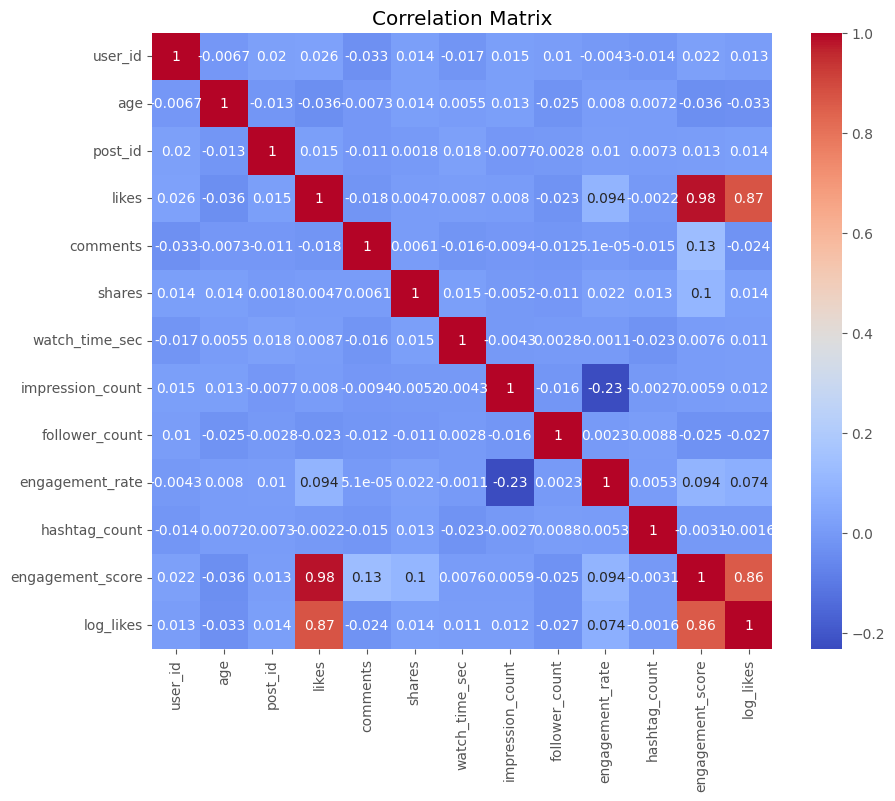

Conclusion:
The heatmap helps identify positive and negative correlations among numerical features.


In [18]:
# Chart 8 – Heatmap
# =====================================================
# CHART 8 : Correlation Matrix
# Objective :
# To understand relationships between numeric variables.
# =====================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

print("Conclusion:")
print("The heatmap helps identify positive and negative correlations among numerical features.")

In [19]:
# Chart 9 – Plotly Interactive Scatter Plot
# =====================================================
# CHART 9 : Interactive Scatter Plot
# Objective :
# To interactively explore the relationship between likes
# and engagement rate based on post type.
# =====================================================

fig = px.scatter(
    df,
    x='likes',
    y='engagement_rate',
    color='post_type',
    title='Likes vs Engagement Rate'
)

fig.show()

print("Conclusion:")
print("The interactive scatter plot helps compare engagement across different post types.")

Conclusion:
The interactive scatter plot helps compare engagement across different post types.


In [20]:
print("=========================================")
print("FINAL INSIGHTS")
print("=========================================")

print("1. Higher likes generally result in higher impressions.")
print("2. Engagement rate varies across different posting dates.")
print("3. Some post categories perform better than others.")
print("4. Positive sentiment posts receive better engagement.")
print("5. Watch time contributes to overall engagement.")
print("6. The correlation matrix reveals relationships among numeric variables.")
print("7. Box plot identifies outliers in engagement rate.")
print("8. Interactive visualization improves understanding of user engagement patterns.")

FINAL INSIGHTS
1. Higher likes generally result in higher impressions.
2. Engagement rate varies across different posting dates.
3. Some post categories perform better than others.
4. Positive sentiment posts receive better engagement.
5. Watch time contributes to overall engagement.
6. The correlation matrix reveals relationships among numeric variables.
7. Box plot identifies outliers in engagement rate.
8. Interactive visualization improves understanding of user engagement patterns.
